In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

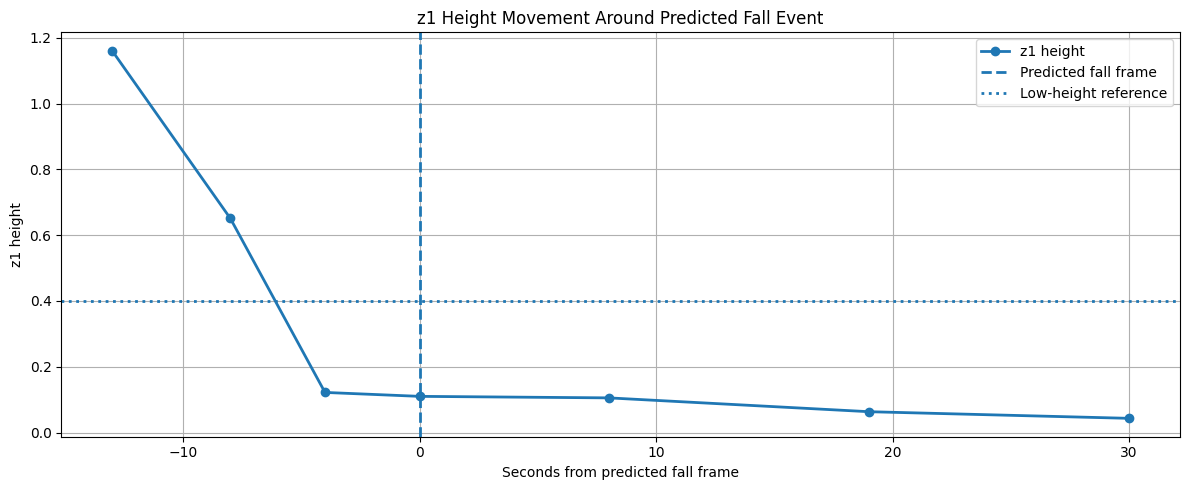

In [2]:
# Visualization for the best fall label
pred = pd.read_csv("fall_prediction_results.csv")
pred["createTime"] = pd.to_datetime(pred["createTime"])

# Pick a clear detected fall event
event_time = pd.to_datetime("2026-03-14 20:05:13")
event_room = "Kitchen"
event_session = 0

window_start = event_time - pd.Timedelta(seconds=40)
window_end = event_time + pd.Timedelta(seconds=40)

event_window = pred[
    (pred["room"] == event_room) &
    (pred["session_id"] == event_session) &
    (pred["createTime"] >= window_start) &
    (pred["createTime"] <= window_end)
].copy()

event_window["seconds_from_event"] = (
    event_window["createTime"] - event_time
).dt.total_seconds()

event_window = event_window.sort_values("seconds_from_event")

plt.figure(figsize=(12, 5))

plt.plot(
    event_window["seconds_from_event"],
    event_window["z1"],
    marker="o",
    linewidth=2,
    label="z1 height"
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=2,
    label="Predicted fall frame"
)

plt.axhline(
    y=0.4,
    linestyle=":",
    linewidth=2,
    label="Low-height reference"
)

plt.title("z1 Height Movement Around Predicted Fall Event")
plt.xlabel("Seconds from predicted fall frame")
plt.ylabel("z1 height")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# python3 fall_data_preprocessing.py --data kitchen_fall_60sec.json --output kitchen_fall_60sec_preprocessed.csv

In [ ]:
# python3 predict_fall_from_csv.py --input kitchen_fall_60sec_preprocessed.csv --model xgboost_fall_detection_model.pkl --threshold 0.35